# Chapter 4: The Path from Prediction to Action

A controller can describe a release without possessing a route that can carry it out. The gap can be a missing interface, a permission check, or a state that must be reached first. Graph reachability turns that gap into an inspectable question: is there a sequence of supported edges from the current state to the intended terminal state?

This notebook keeps the raw graph and the permission-filtered graph separate. A raw path describes what the assembled interface could permit in some authority configuration. An allowed path describes what this frozen configuration permits now. Neither path is an execution receipt. The example includes a loop back to drafting and an archive sink, so reachability does not become a disguised claim of inevitable progress.

**Outcome:** Return reachable states, a permitted path, and sinks under frozen permissions.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let G=(V,E) be a directed graph of declared states and action interfaces. Permission filtering forms E_allowed={e in E: allowed(e)=true}. A goal is reachable when some finite directed path from the start ends at it. Breadth-first search discovers the minimum number of edges needed to reach each node in an unweighted graph.

The algorithm maintains a queue and a distance map. The start has distance zero. Each previously unseen neighbor receives its predecessor's distance plus one and enters the queue. Recording predecessors reconstructs one shortest path to the goal. A visited set prevents a cycle from making the search loop forever.

A reachable sink is a discovered node with no outgoing permitted edge. It can represent successful termination, a dead end, or an intentional refusal state; the graph alone does not tell you which. The cumulative depth figure counts how many allowed nodes can be reached within each maximum path length. Removing a bridge can disconnect a goal even when the raw graph remains connected.

## A calculation you can run

Register every node, then supply directed edges with exact boolean permission flags. The start and goal must be registered, and every edge endpoint must be known. The function runs breadth-first search on the raw adjacency map and on the permission-filtered map, returning reachable counts and paths separately.

The chart places maximum path length on the horizontal axis and cumulative reachable-node count on the vertical axis. It describes possibilities under the current graph. For the changed case, remove permission from the review-to-release edge. Predict the goal result before running the function. Inspect the returned sink list and distance map to understand where the permitted workflow can end. This is more useful than reporting only a yes/no path flag.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 4
inputs = {'nodes': ['draft', 'review', 'release', 'archive'],
 'start': 'draft',
 'goal': 'release',
 'edges': [{'from': 'draft', 'to': 'review', 'allowed': True},
           {'from': 'review', 'to': 'release', 'allowed': True},
           {'from': 'review', 'to': 'draft', 'allowed': True},
           {'from': 'draft', 'to': 'archive', 'allowed': True}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 4: permission-reachability
Is there a permitted path from the current state to the intended effect?
Evidence: constructed teaching example

Calculated quantities:
{
  "raw_reachable": true,
  "authorized_reachable": true,
  "authorized_path": [
    "draft",
    "review",
    "release"
  ],
  "raw_count": 4,
  "authorized_count": 4,
  "reachable_sinks": [
    "archive",
    "release"
  ]
}

Interpretation:
A path is a sequence of permitted possibilities. It does not establish that any action occurred.

Assumptions:
- Permissions are frozen at analysis time.
- Directed edges describe actual supported interfaces.

Limitations:
- Dynamic permission changes and hidden preconditions require a richer state graph.

Execution: completed locally; constructed inputs are not deployment measurements.


The default goal is reachable through draft, review, release. All four nodes are reachable because archive is also available directly from draft. The review-to-draft loop does not change the shortest path and does not prevent the search from terminating.

In the changed case, the raw path still exists but the authorized path is empty. Release is absent from the allowed distance map. Draft, review, and archive remain reachable, so the reachable count falls from four to three. The controller has lost an authority bridge, not a linguistic ability to mention release. A useful report names that missing edge and the authority required to restore it.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


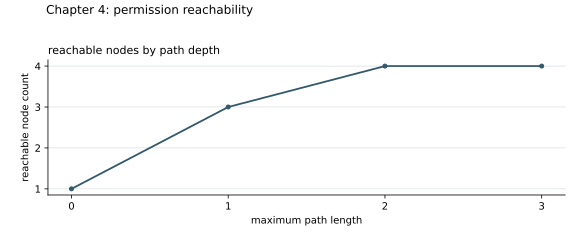

In [3]:
display(SVG(figure_svg(report)))

**Figure 4.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Reachability is necessary for many workflow goals but is not sufficient for completion. An edge might represent a probabilistic tool action, an expensive operation, or a choice the policy never selects. Those conditions need a transition model and policy analysis rather than a plain graph. Likewise, permission can change between observation and action, invalidating the frozen snapshot.

An unsafe inference is to interpret a path containing an unallowed edge as permission to execute it. The raw graph is a diagnostic comparison, not an alternate authority source. The transfer case makes this explicit: the final edge exists, but the controller cannot reach the state from which it becomes available.

Graph design also matters. If the node label hides document version or review status, the graph can claim a path that the real state machine forbids. Include the relevant state boundary before treating reachability as an operational result.

Chapter 4: permission-reachability
Is there a permitted path from the current state to the intended effect?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "raw_reachable": true,
  "authorized_reachable": false,
  "authorized_path": [],
  "raw_count": 4,
  "authorized_count": 3,
  "reachable_sinks": [
    "archive"
  ]
}

Interpretation:
A path is a sequence of permitted possibilities. It does not establish that any action occurred.

Assumptions:
- Permissions are frozen at analysis time.
- Directed edges describe actual supported interfaces.

Limitations:
- Dynamic permission changes and hidden preconditions require a richer state graph.

Execution: completed locally; constructed inputs are not deployment measurements.


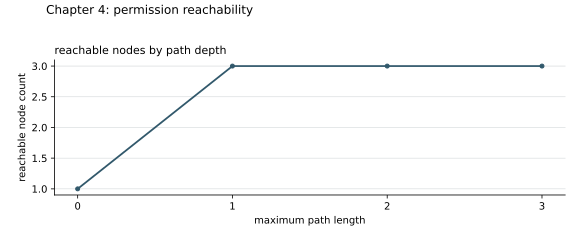

In [4]:
changed_inputs = {'nodes': ['draft', 'review', 'release', 'archive'],
 'start': 'draft',
 'goal': 'release',
 'edges': [{'from': 'draft', 'to': 'review', 'allowed': True},
           {'from': 'review', 'to': 'release', 'allowed': False},
           {'from': 'review', 'to': 'draft', 'allowed': True},
           {'from': 'draft', 'to': 'archive', 'allowed': True}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 4.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer workflow starts queued and requires approval before sending. The queued-to-approved edge is denied, so neither approved nor sent is reachable from the start under current permissions. A permitted approved-to-sent edge cannot help until its initiation state is reached.

For local use, map concrete tool preconditions and current authority into nodes and edges. Distinguish a terminal refusal from an accidental dead end. After computing a path, export its ordered states and the frozen permission contract. Use a separate execution trace to establish whether the actions happened, and recheck authority at the action boundary when permissions can change.

In [5]:
transfer_inputs = {'nodes': ['queued', 'approved', 'sent'],
 'start': 'queued',
 'goal': 'sent',
 'edges': [{'from': 'queued', 'to': 'approved', 'allowed': False},
           {'from': 'approved', 'to': 'sent', 'allowed': True}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 4: permission-reachability
Is there a permitted path from the current state to the intended effect?
Evidence: constructed transfer example

Calculated quantities:
{
  "raw_reachable": true,
  "authorized_reachable": false,
  "authorized_path": [],
  "raw_count": 3,
  "authorized_count": 1,
  "reachable_sinks": [
    "queued"
  ]
}

Interpretation:
A path is a sequence of permitted possibilities. It does not establish that any action occurred.

Assumptions:
- Permissions are frozen at analysis time.
- Directed edges describe actual supported interfaces.

Limitations:
- Dynamic permission changes and hidden preconditions require a richer state graph.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **nodes:** Unique nonempty state identifiers.
- **start:** Registered initial node.
- **goal:** Registered desired node.
- **edges:** Directed edge list with from,to:registered identifiers and allowed:exact boolean.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch04.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 4: permission-reachability
Is there a permitted path from the current state to the intended effect?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "raw_reachable": true,
  "authorized_reachable": false,
  "authorized_path": [],
  "raw_count": 3,
  "authorized_count": 1,
  "reachable_sinks": [
    "queued"
  ]
}

Interpretation:
A path is a sequence of permitted possibilities. It does not establish that any action occurred.

Assumptions:
- Permissions are frozen at analysis time.
- Directed edges describe actual supported interfaces.

Limitations:
- Dynamic permission changes and hidden preconditions require a richer state graph.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. What is the default shortest authorized path?

2. Does the changed raw graph still reach release?

3. Why is the transfer send action unusable?

Answers: [separate solutions](../solutions/ch04.md). Try the calculation before opening them.

## Summary

A graph separates describing an action from possessing an executable route to it. Permission filtering can remove a crucial bridge while leaving the raw interface graph intact. Breadth-first search returns a path, distances, and reachable sinks without confusing cycles with progress. The default route exists; the changed route is denied; the transfer route is blocked before approval. Keep the graph's state detail and authority snapshot explicit. Reachability reports possible paths, while completed effects require execution and confirmation evidence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-04-permission-reachability`](../skills/maa-04-permission-reachability/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 4.1

![Equation 4.1](../assets/math/bed64e2dcf2437c58994.svg)

Equation (4.1) asks the most literal question available about a system: starting here, what states can it get to at all?

Take the initial states, apply the transition relation zero times, once, twice, and so on, and collect everything reachable in any number of steps.

LaTeX source, preserved for inspection:

```latex
\operatorname{Reach}_G(V_0)=
\bigcup_{t\geq0}\operatorname{step}^{t}(V_0).
\tag{4.1}
```

### Equation 4.2

![Equation 4.2](../assets/math/3a0a8d81e19f9cf8e5b5.svg)

Equation (4.2) says a permission system does not comment on a proposed action, it decides which proposals can be attempted at all.

Take every candidate action available at the state, pass the whole set through the grant rule, and keep what survives.

LaTeX source, preserved for inspection:

```latex
\operatorname{Allowed}_{\mathcal G}(v)=\mathcal{G}\bigl(\operatorname{Act}(v)\bigr).
\tag{4.2}
```

### Equation 4.3

![Equation 4.3](../assets/math/fa364432e1111d4198e2.svg)

Equation (4.3) defines, for the declared infinite graph and independent edge-retention model, the probability that the starting vertex belongs to an infinite open cluster, and the threshold for that probability to become positive.

The first quantity is the chance that the cluster containing the starting vertex is infinite; the threshold is the infimum of edge probabilities making that chance positive, and need not itself have positive survival probability.

LaTeX source, preserved for inspection:

```latex
\begin{gathered}
\Pi_{G,v}(p)=\Pr_p\{|C_p(v)|=\infty\},\\
p_c(G,v)=\inf\{p:\Pi_{G,v}(p)>0\}.
\end{gathered}
\tag{4.3}
```

### Equation 4.4

![Equation 4.4](../assets/math/f90dc3b1b6125fdae3df.svg)

Equation (4.4) gives the exact threshold for one solvable graph shape, so the whole argument has a number rather than an intuition.

Divide one by the number of children each vertex has; that edge probability is where isolated pockets give way to an unbounded cluster.

LaTeX source, preserved for inspection:

```latex
p_c=\frac{1}{d}.
\tag{4.4}
```

### Equation un-numbered display 5

![Equation un-numbered display 5](../assets/math/d443a7a79a40512d1cac.svg)



LaTeX source, preserved for inspection:

```latex
1-[1-0.6(1-0.4^2)]^2=0.753984.
```

### Equation un-numbered display 6

![Equation un-numbered display 6](../assets/math/3d80cc5345e1f3c227ed.svg)



LaTeX source, preserved for inspection:

```latex
p = p_{\text{format}}\times p_{\text{parse}}\times p_{\text{grant}}\times p_{\text{tool}}.
```

### Equation un-numbered display 7

![Equation un-numbered display 7](../assets/math/8d6a53c3f7a2ddb2e2b2.svg)



LaTeX source, preserved for inspection:

```latex
p = 0.95\times0.98\times0.90\times0.80 = 0.67032,
```

### Equation un-numbered display 8

![Equation un-numbered display 8](../assets/math/4a0b93e9247d55068352.svg)



LaTeX source, preserved for inspection:

```latex
p = 0.95\times0.98\times0.40\times0.80 = 0.29792,
\qquad
pd = 0.59584.
```